In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import sys
import os
from pathlib import Path
from datetime import datetime
from scipy.stats import lognorm

project_root = Path.cwd().parent.parent
project_root_str = str(project_root)

if project_root_str not in sys.path:
    sys.path.insert(0, project_root_str)

os.chdir(project_root_str)


from src.pipeline.calculate_evs import *
from src.utils.helper_functions import *
from src.features.ngboost_points import *
from src.features.feature_engine import FeatureEngine
from src.utils.team_info import teamStarPlayer, projectedStartingFive, mainStartingFive
from src.models.ngboost_model import predict_mean
from src.pipeline.pipeline_pts import build_ngboost_points_features

/Users/alexgonzalez/Documents/NBA-Prop-Predictor/nba_model/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [9]:
ANALYSIS_DATE = "2025-12-08" 

pd.set_option('display.max_columns', None)

today = datetime.today().strftime('%Y%m%d')  
current_date = datetime.now().strftime('%Y-%m-%d')

def get_latest_file(pattern):
    files = list(Path('data/raw/player_lines').glob(pattern))
    if not files:
        return None
    return max(files, key=lambda p: p.stat().st_mtime)

us_file = get_latest_file(f'NBA_US_{today}*.csv')
dfs_file = get_latest_file(f'NBA_DFS_{today}*.csv')

if us_file is None:
    raise FileNotFoundError(f"No NBA_US file found for {today}")
if dfs_file is None:
    raise FileNotFoundError(f"No NBA_DFS file found for {today}")

s26 = pd.read_csv('data/processed/training/PTS_TRAIN_26.csv').sort_values(by='GAME_DATE')
usData = pd.read_csv(us_file)
dfsData = pd.read_csv(dfs_file)

print(f"Loaded: {us_file.name}")
print(f"Loaded: {dfs_file.name}")
dfsData.head()

Loaded: NBA_US_20251209_121100.csv
Loaded: NBA_DFS_20251209_121139.csv


,BOOKMAKER,CATEGORY,NAME,OVER/UNDER,LINE,ODDS,COMMENCE_TIME,LAST_UPDATE,DATA_PULLED_AT
0,Underdog,player_points,Paolo Banchero,Over,20.5,-137,2025-12-09,2025-12-09T20:10:56Z,2025-12-09 12:11:39
1,Underdog,player_points,Paolo Banchero,Under,20.5,-137,2025-12-09,2025-12-09T20:10:56Z,2025-12-09 12:11:39
2,Underdog,player_points,Desmond Bane,Over,22.5,-137,2025-12-09,2025-12-09T20:10:56Z,2025-12-09 12:11:39
3,Underdog,player_points,Desmond Bane,Under,22.5,-137,2025-12-09,2025-12-09T20:10:56Z,2025-12-09 12:11:39
4,Underdog,player_points,Bam Adebayo,Over,18.5,-137,2025-12-09,2025-12-09T20:10:56Z,2025-12-09 12:11:39


In [29]:
# Initialize model engine
engine = FeatureEngine({
    "min_model": "src/models/saved/min_model.pkl",
    "usg_model": "src/models/saved/usg_model.pkl",
    "fga_model": "src/models/saved/fga_model.pkl",
    "ngboost_model_wrapper": "src/models/saved/pts_model_wrapper.pkl"
})

bookmakers = ['PrizePicks', 'Underdog']
all_players = dfsData[dfsData['BOOKMAKER'].isin(bookmakers) & (dfsData['CATEGORY'] == 'player_points')]
all_players = all_players['NAME'].unique()
all_players

array(['Paolo Banchero', 'Desmond Bane', 'Bam Adebayo', 'Tyler Herro',
       'Jalen Suggs', 'Wendell Carter Jr', 'Norman Powell', 'Tyus Jones',
       'Davion Mitchell', 'Anthony Black', "Kel'el Ware",
       'Tristan da Silva', 'Scottie Barnes', 'Jalen Brunson',
       'Karl-Anthony Towns', 'Brandon Ingram', 'OG Anunoby',
       'Immanuel Quickley', 'Josh Hart', 'Mikal Bridges', 'Jamal Shead',
       "Ja'Kobe Walter", 'Sandro Mamukelashvili', 'Andrew Wiggins',
       'Jaime Jaquez Jr', 'Goga Bitadze', 'Jordan Clarkson',
       'Jakob Poeltl', 'Shai Gilgeous-Alexander', 'Devin Booker',
       'Dillon Brooks', 'Jalen Williams', 'Chet Holmgren',
       'Grayson Allen', 'Cason Wallace', 'Luka Doncic', 'Austin Reaves',
       "De'Aaron Fox", 'Victor Wembanyama', 'LeBron James'], dtype=object)

In [30]:
from src.utils.team_info import nameDict

results = []
for player in all_players:
    if player in nameDict:
        player = nameDict[player]
    result = engine.project_player(
    player_name=player,
    data=s26,
    date='2025-12-09',  # Uses the date set in Cell 1
    projectedStartingFive=projectedStartingFive,
    mainStartingFive=mainStartingFive,
    teamStarPlayer=teamStarPlayer,
    league_df=league_df,
    findOpp=findOpp)
    if result is None:
        continue
    results.append({
        'player': player,
        'predicted_points': round(result['predicted_points'],2),
        'predicted_minutes': round(result['predicted_minutes'],2),
        'predicted_usage': round(result['predicted_usage'],3),
        'predicted_fga': round(result['predicted_fga'],2)
    })
results = pd.DataFrame(results)
results.to_csv(f'/Users/alexgonzalez/Documents/NBA-Prop-Predictor/notebooks/exploration/old_predictions/player_predictions_{today}.csv')


[MIN] No data found for Wendell Carter Jr


In [31]:
name = 'Desmond Bane'
betting_line = 22.5 
odds = -137
# ============================================================================

print(f"🏀 Analyzing: {name}")
print(f"📊 Betting Line: {betting_line} points (Odds: {odds})")

🏀 Analyzing: Desmond Bane
📊 Betting Line: 22.5 points (Odds: -137)


In [32]:
def get_actual_result(player_name, game_date, data):
    """Get actual game result for a player on a specific date"""
    player_data = data[
        (data['PLAYER_NAME'] == player_name) & 
        (data['GAME_DATE'] == game_date)
    ]
    
    if len(player_data) == 0:
        return None
    
    actual = player_data.iloc[0]
    return {
        'actual_points': actual['PTS'],
        'actual_minutes': actual['MIN'],
        'actual_fga': actual['FGA'],
        'actual_fgm': actual['FGM'],
        'actual_fg_pct': actual['FG_PCT'],
        'actual_fg3a': actual['FG3A'],
        'actual_fg3m': actual['FG3M'],
        'actual_fta': actual['FTA'],
        'actual_ftm': actual['FTM'],
        'actual_usage': actual['USG_PCT'],
        'actual_ts_pct': actual['TS_PCT'],
        'actual_plus_minus': actual['PLUS_MINUS'],
        'team_pace': actual['TEAM_PACE'],
        'opp_def_rating': actual['OPP_DEF_RATING'],
        'matchup': actual['MATCHUP'],
        'starting': actual['STARTING'],
        'team_wl': actual['WL'],
        'star_out': actual['STAR_SAT_OUT'],
        'star': actual['PLAYER_IS_TEAM_STAR']
    }

# Get actual result
actual_result = get_actual_result(name, ANALYSIS_DATE, s26)

if actual_result:
    print("=" * 60)
    print(f"ANALYSIS FOR: {name}")
    print(f"Game Date: {ANALYSIS_DATE}")
    print(f"Matchup: {actual_result['matchup']}")
    print(f"Result: {actual_result['team_wl']}")
    print("=" * 60)
    
    # Points comparison
    pred_points = result['predicted_points']
    actual_points = actual_result['actual_points']
    line_diff_pred = pred_points - betting_line
    line_diff_actual = actual_points - betting_line
    pred_error = pred_points - actual_points
    
    print(f"\n🎯 POINTS:")
    print(f"  Betting Line:        {betting_line:.2f}")
    print(f"  Model Prediction:    {pred_points:.2f} ({line_diff_pred:+.2f} vs line)")
    print(f"  Actual Result:       {actual_points:.2f} ({line_diff_actual:+.2f} vs line)")
    print(f"  Prediction Error:    {pred_error:+.2f}")
    print(f"  Error %:             {(pred_error/actual_points*100):+.1f}%")
    
    # Determine bet outcome
    print(f"\n💰 BET OUTCOME:")
    actual_hit_over = "✅" if actual_points > betting_line else "❌"
    pred_hit_over = "✅" if pred_points > betting_line else "❌"
    print(f"  Actual vs Line:      {actual_hit_over} {'OVER' if actual_points > betting_line else 'UNDER'}")
    print(f"  Model Predicted:     {pred_hit_over} {'OVER' if pred_points > betting_line else 'UNDER'}")
    print(f"  Model Correct:       {'✅ YES' if (actual_points > betting_line) == (pred_points > betting_line) else '❌ NO'}")
    
    # Minutes comparison
    pred_min = result['predicted_minutes']
    actual_min = actual_result['actual_minutes']
    min_error = pred_min - actual_min
    
    print(f"\n⏱️  MINUTES:")
    print(f"  Model Prediction:    {pred_min:.2f}")
    print(f"  Actual Result:       {actual_min:.2f}")
    print(f"  Error:               {min_error:+.2f} ({(min_error/actual_min*100):+.1f}%)")
    
    # Usage comparison
    pred_usg = result['predicted_usage']
    actual_usg = actual_result['actual_usage']
    usg_error = pred_usg - actual_usg
    
    print(f"\n📈 USAGE RATE:")
    print(f"  Model Prediction:    {pred_usg:.3f}")
    print(f"  Actual Result:       {actual_usg:.3f}")
    print(f"  Error:               {usg_error:+.3f}")
    
    # FGA comparison
    pred_fga = result['predicted_fga']
    actual_fga = actual_result['actual_fga']
    fga_error = pred_fga - actual_fga
    
    print(f"\n🏀 FIELD GOAL ATTEMPTS:")
    print(f"  Model Prediction:    {pred_fga:.2f}")
    print(f"  Actual Result:       {actual_fga:.2f}")
    print(f"  Error:               {fga_error:+.2f}")
    
    # Shooting efficiency
    actual_fg_pct = actual_result['actual_fg_pct']
    actual_ts_pct = actual_result['actual_ts_pct']
    
    print(f"\n🎯 SHOOTING EFFICIENCY:")
    print(f"  Actual FG%:          {actual_fg_pct:.3f}")
    print(f"  Actual TS%:          {actual_ts_pct:.3f}")
    print(f"  FGM/FGA:             {actual_result['actual_fgm']}/{actual_result['actual_fga']}")
    print(f"  3PM/3PA:             {actual_result['actual_fg3m']}/{actual_result['actual_fg3a']}")
    print(f"  FTM/FTA:             {actual_result['actual_ftm']}/{actual_result['actual_fta']}")
    
    # Game context
    print(f"\nGAME CONTEXT:")
    print(f"  Starting:            {actual_result['starting']}")
    print(f"  Star Out:            {actual_result['star_out']}")
    print(f"  Star:                {actual_result['star']}")
    print(f"  Team Pace:           {actual_result['team_pace']:.2f}")
    print(f"  Opp Def Rating:      {actual_result['opp_def_rating']:.2f}")
    print(f"  Plus/Minus:          {actual_result['actual_plus_minus']:+.0f}")
    
else:
    print(f"No actual data found for {name}")
    print("The game may not have been played yet or data hasn't been updated.")


No actual data found for Desmond Bane
The game may not have been played yet or data hasn't been updated.


In [16]:
# Deep dive: What context did the model miss?
if actual_result:
    print("\n" + "=" * 60)
    print("🔍 WHAT CONTEXT DID THE MODEL MISS?")
    print("=" * 60)
    
    # Get player's recent games
    player_recent = s26[
        (s26['PLAYER_NAME'] == name) & 
        (s26['GAME_DATE'] < "2025-12-07")
    ].sort_values('GAME_DATE', ascending=False).head(10)
    
    # Analyze recent form
    if len(player_recent) > 0:
        print("\n📈 RECENT FORM (Last 10 games):")
        print("-" * 60)
        print(f"  Avg Points:          {player_recent['PTS'].mean():.2f}")
        print(f"  Points Std Dev:      {player_recent['PTS'].std():.2f}")
        print(f"  Avg Minutes:         {player_recent['MIN'].mean():.2f}")
        print(f"  Avg FGA:             {player_recent['FGA'].mean():.2f}")
        print(f"  Avg Usage:           {player_recent['USG_PCT'].mean():.3f}")
        print(f"  Avg TS%:             {player_recent['TS_PCT'].mean():.3f}")
        
        # Last 3 games
        last_3 = player_recent.head(3)
        print(f"\n  Last 3 games PTS:    {list(last_3['PTS'].values)}")
        print(f"  Last 3 games MIN:    {[f'{m:.1f}' for m in last_3['MIN'].values]}")
        
    # Matchup history
    opp_abbrev = s26[s26['PLAYER_NAME'] == name]['OPP_ABBREVIATION'].values[0]
    matchup_history = s26[
        (s26['PLAYER_NAME'] == name) & 
        (s26['OPP_ABBREVIATION'] == opp_abbrev)
    ].sort_values('GAME_DATE', ascending=False).head(5)
    
    if len(matchup_history) > 0:
        print(f"\n🏀 MATCHUP HISTORY vs {opp_abbrev}:")
        print("-" * 60)
        print(f"  Games Played:        {len(matchup_history)}")
        print(f"  Avg Points:          {matchup_history['PTS'].mean():.2f}")
        print(f"  Avg Minutes:         {matchup_history['MIN'].mean():.2f}")
        print(f"  Recent scores:       {list(matchup_history['PTS'].head(3).values)}")
    else:
        print(f"\n🏀 MATCHUP HISTORY vs {opp_abbrev}:")
        print("-" * 60)
        print("  No recent matchup history found")
    
    # Model component breakdown
    print("\n⚙️  MODEL COMPONENT BREAKDOWN:")
    print("-" * 60)
    
    # Minutes impact
    if actual_result and result:
        min_impact_on_pts = (actual_result['actual_minutes'] / result['predicted_minutes']) * result['predicted_points']
        print(f"  If we knew actual minutes:")
        print(f"    Adjusted prediction: {min_impact_on_pts:.2f} pts")
        print(f"    Would reduce error by: {abs(result['predicted_points'] - actual_result['actual_points']) - abs(min_impact_on_pts - actual_result['actual_points']):.2f} pts")
    
    # Usage impact
    if actual_result and result:
        usg_impact_on_pts = (actual_result['actual_usage'] / result['predicted_usage']) * result['predicted_points']
        print(f"\n  If we knew actual usage rate:")
        print(f"    Adjusted prediction: {usg_impact_on_pts:.2f} pts")
        print(f"    Would reduce error by: {abs(result['predicted_points'] - actual_result['actual_points']) - abs(usg_impact_on_pts - actual_result['actual_points']):.2f} pts")
    
    # Efficiency impact
    if actual_result:
        implied_pts_per_fga = actual_result['actual_points'] / actual_result['actual_fga'] if actual_result['actual_fga'] > 0 else 0
        expected_pts_from_fga = result['predicted_fga'] * implied_pts_per_fga
        print(f"\n  If we knew actual shooting efficiency:")
        print(f"    Actual pts/FGA:      {implied_pts_per_fga:.2f}")
        print(f"    Expected from pred FGA: {expected_pts_from_fga:.2f} pts")
    
    # Key insights
    print("\n💡 KEY INSIGHTS:")
    print("-" * 60)
    
    # Minutes variance
    if abs(min_error) > 5:
        print(f"  ⚠️  Large minutes error ({min_error:+.1f} min)")
        print(f"      Model may have missed rotations/game flow")
    
    # Usage variance
    if abs(usg_error) > 0.05:
        print(f"  ⚠️  Large usage error ({usg_error:+.3f})")
        print(f"      Model may have missed team dynamics/playmaking")
    
    # Shooting variance
    if len(player_recent) > 0:
        recent_ts = player_recent['TS_PCT'].mean()
        ts_diff = actual_result['actual_ts_pct'] - recent_ts
        if abs(ts_diff) > 0.10:
            print(f"  ⚠️  Unusual shooting performance")
            print(f"      Recent TS%: {recent_ts:.3f}, Actual: {actual_result['actual_ts_pct']:.3f}")
            print(f"      Player shot {'better' if ts_diff > 0 else 'worse'} than usual")
    
    # Game script
    if actual_result['actual_plus_minus'] < -15:
        print(f"  ⚠️  Blowout loss (Plus/Minus: {actual_result['actual_plus_minus']:+.0f})")
        print(f"      Garbage time may have affected playing time/usage")
    elif actual_result['actual_plus_minus'] > 15:
        print(f"  ⚠️  Blowout win (Plus/Minus: {actual_result['actual_plus_minus']:+.0f})")
        print(f"      May have sat out 4th quarter")
    
    # FGA variance
    if abs(fga_error) > 5:
        print(f"  ⚠️  Large FGA error ({fga_error:+.1f} attempts)")
        print(f"      Model may have missed offensive role/opportunities")



🔍 WHAT CONTEXT DID THE MODEL MISS?

📈 RECENT FORM (Last 10 games):
------------------------------------------------------------
  Avg Points:          7.00
  Points Std Dev:      3.59
  Avg Minutes:         16.62
  Avg FGA:             6.50
  Avg Usage:           0.180
  Avg TS%:             0.524

  Last 3 games PTS:    [np.int64(6), np.int64(7), np.int64(10)]
  Last 3 games MIN:    ['14.1', '16.2', '22.2']

🏀 MATCHUP HISTORY vs MEM:
------------------------------------------------------------
  Games Played:        2
  Avg Points:          11.00
  Avg Minutes:         16.17
  Recent scores:       [np.int64(14), np.int64(8)]

⚙️  MODEL COMPONENT BREAKDOWN:
------------------------------------------------------------
  If we knew actual minutes:
    Adjusted prediction: 2.17 pts
    Would reduce error by: 5.61 pts

  If we knew actual usage rate:
    Adjusted prediction: 12.48 pts
    Would reduce error by: -4.71 pts

  If we knew actual shooting efficiency:
    Actual pts/FGA:      0

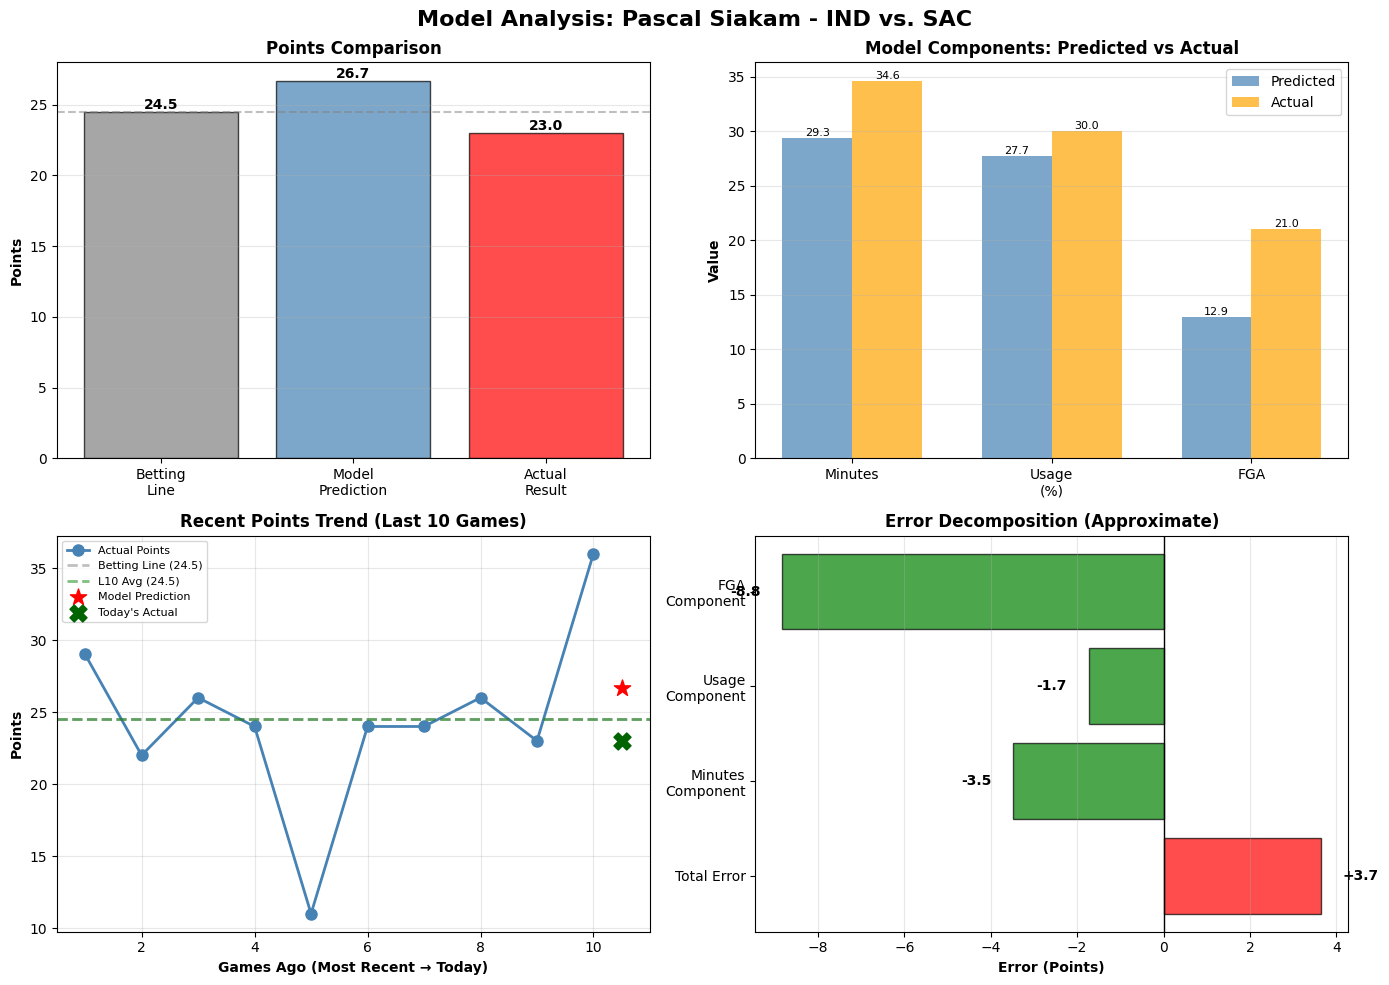

In [8]:
# Visualizations for single player analysis
if actual_result and result:
    # Get player's recent games for trend visualization
    player_recent = s26[
        (s26['PLAYER_NAME'] == name.strip()) & 
        (s26['GAME_DATE'] < ANALYSIS_DATE)
    ].sort_values('GAME_DATE', ascending=False).head(10)
    
    # Calculate errors for visualization
    pred_error = result['predicted_points'] - actual_result['actual_points']
    min_error = result['predicted_minutes'] - actual_result['actual_minutes']
    usg_error = result['predicted_usage'] - actual_result['actual_usage']
    fga_error = result['predicted_fga'] - actual_result['actual_fga']
    
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    fig.suptitle(f'Model Analysis: {name.strip()} - {actual_result["matchup"]}', fontsize=16, fontweight='bold')
    
    # 1. Points comparison bar chart
    ax1 = axes[0, 0]
    categories = ['Betting\nLine', 'Model\nPrediction', 'Actual\nResult']
    values = [betting_line, result['predicted_points'], actual_result['actual_points']]
    colors = ['gray', 'steelblue', 'green' if actual_result['actual_points'] > betting_line else 'red']
    
    bars = ax1.bar(categories, values, color=colors, alpha=0.7, edgecolor='black')
    ax1.axhline(y=betting_line, color='gray', linestyle='--', alpha=0.5, label='Betting Line')
    ax1.set_ylabel('Points', fontweight='bold')
    ax1.set_title('Points Comparison', fontweight='bold')
    ax1.grid(axis='y', alpha=0.3)
    
    # Add value labels on bars
    for bar in bars:
        height = bar.get_height()
        ax1.text(bar.get_x() + bar.get_width()/2., height,
                f'{height:.1f}',
                ha='center', va='bottom', fontweight='bold')
    
    # 2. Component comparison (Min, Usage, FGA)
    ax2 = axes[0, 1]
    components = ['Minutes', 'Usage\n(%)', 'FGA']
    pred_values = [result['predicted_minutes'], result['predicted_usage']*100, result['predicted_fga']]
    actual_values = [actual_result['actual_minutes'], actual_result['actual_usage']*100, actual_result['actual_fga']]
    
    x = np.arange(len(components))
    width = 0.35
    
    bars1 = ax2.bar(x - width/2, pred_values, width, label='Predicted', color='steelblue', alpha=0.7)
    bars2 = ax2.bar(x + width/2, actual_values, width, label='Actual', color='orange', alpha=0.7)
    
    ax2.set_ylabel('Value', fontweight='bold')
    ax2.set_title('Model Components: Predicted vs Actual', fontweight='bold')
    ax2.set_xticks(x)
    ax2.set_xticklabels(components)
    ax2.legend()
    ax2.grid(axis='y', alpha=0.3)
    
    # Add value labels
    for bars in [bars1, bars2]:
        for bar in bars:
            height = bar.get_height()
            ax2.text(bar.get_x() + bar.get_width()/2., height,
                    f'{height:.1f}',
                    ha='center', va='bottom', fontsize=8)
    
    # 3. Recent points trend
    ax3 = axes[1, 0]
    if len(player_recent) > 0:
        recent_games = player_recent.head(10).sort_values('GAME_DATE')
        game_nums = range(1, len(recent_games) + 1)
        
        ax3.plot(game_nums, recent_games['PTS'].values, marker='o', linestyle='-', 
                linewidth=2, markersize=8, color='steelblue', label='Actual Points')
        ax3.axhline(y=betting_line, color='gray', linestyle='--', linewidth=2, 
                   alpha=0.5, label=f'Betting Line ({betting_line})')
        ax3.axhline(y=recent_games['PTS'].mean(), color='green', linestyle='--', 
                   linewidth=2, alpha=0.5, label=f'L10 Avg ({recent_games["PTS"].mean():.1f})')
        
        # Mark today's prediction
        ax3.scatter([len(game_nums) + 0.5], [result['predicted_points']], 
                   color='red', s=150, marker='*', zorder=5, label='Model Prediction')
        ax3.scatter([len(game_nums) + 0.5], [actual_result['actual_points']], 
                   color='darkgreen', s=150, marker='X', zorder=5, label='Today\'s Actual')
        
        ax3.set_xlabel('Games Ago (Most Recent → Today)', fontweight='bold')
        ax3.set_ylabel('Points', fontweight='bold')
        ax3.set_title('Recent Points Trend (Last 10 Games)', fontweight='bold')
        ax3.legend(loc='best', fontsize=8)
        ax3.grid(alpha=0.3)
        ax3.set_xlim(0.5, len(game_nums) + 1)
    else:
        ax3.text(0.5, 0.5, 'No recent game data', ha='center', va='center', 
                transform=ax3.transAxes, fontsize=12)
        ax3.set_title('Recent Points Trend', fontweight='bold')
    
    # 4. Error breakdown
    ax4 = axes[1, 1]
    error_components = {
        'Total Error': pred_error,
        'Minutes\nComponent': (min_error / actual_result['actual_minutes']) * actual_result['actual_points'] if actual_result['actual_minutes'] > 0 else 0,
        'Usage\nComponent': (usg_error / actual_result['actual_usage']) * actual_result['actual_points'] if actual_result['actual_usage'] > 0 else 0,
        'FGA\nComponent': (fga_error / actual_result['actual_fga']) * actual_result['actual_points'] if actual_result['actual_fga'] > 0 else 0,
    }
    
    components_list = list(error_components.keys())
    errors = list(error_components.values())
    colors_err = ['red' if e > 0 else 'green' for e in errors]
    
    bars = ax4.barh(components_list, errors, color=colors_err, alpha=0.7, edgecolor='black')
    ax4.axvline(x=0, color='black', linestyle='-', linewidth=1)
    ax4.set_xlabel('Error (Points)', fontweight='bold')
    ax4.set_title('Error Decomposition (Approximate)', fontweight='bold')
    ax4.grid(axis='x', alpha=0.3)
    
    # Add value labels
    for i, (bar, val) in enumerate(zip(bars, errors)):
        ax4.text(val + (0.5 if val > 0 else -0.5), i, f'{val:+.1f}',
                va='center', ha='left' if val > 0 else 'right', fontweight='bold')
    
    plt.tight_layout()
    plt.show()
else:
    if not actual_result:
        print("⚠️  No visualizations available - missing actual data")
    elif not result:
        print("⚠️  No visualizations available - prediction failed")
    else:
        print("⚠️  No visualizations available - missing data")

## OVERALL ANALYSIS OF ALL PREDICTIONS

In [8]:
# Load EV data for today
ev_file = Path('notebooks/exploration/old_evs/singleBets_PP_2025-12-08.csv')
ev_data = pd.read_csv(ev_file)

# Batch Analysis: Compare multiple players using EV data
def analyze_multiple_props_from_ev(ev_df, game_date, data):
    results = []
    
    print(f"📊 Processing {len(ev_df)} props from EV data...")
    
    for _, prop in ev_df.iterrows():
        player_name = prop['NAME'].strip()  # Strip whitespace to avoid matching issues
        betting_line = prop['LINE']
        odds = prop.get('ODDS', -137)
        prediction = prop['PREDICTION']  # Use prediction from EV file
        side = prop.get('SIDE', 'over')
        model_prob = prop.get('MODEL_PROB', 0.5)
        edge = prop.get('EDGE', 0.0)
        ev_percent = prop.get('EV_PERCENT', 0.0)
        
        # Get actual result
        try:
            actual = get_actual_result(player_name, game_date, data)
            
            if actual:
                actual_points = actual['actual_points']
                
                # Determine if prediction hit based on side
                if side == 'over':
                    pred_hit = prediction > betting_line
                    actual_hit = actual_points > betting_line
                else:  # under
                    pred_hit = prediction < betting_line
                    actual_hit = actual_points < betting_line
                
                results.append({
                    'player': player_name,
                    'line': betting_line,
                    'side': side,
                    'prediction': prediction,
                    'actual': actual_points,
                    'pred_error': prediction - actual_points,
                    'pred_error_pct': (prediction - actual_points) / actual_points * 100 if actual_points > 0 else 0,
                    'pred_vs_line': prediction - betting_line if side == 'over' else betting_line - prediction,
                    'actual_vs_line': actual_points - betting_line if side == 'over' else betting_line - actual_points,
                    'model_correct': actual_hit == pred_hit,
                    'actual_hit': actual_hit,
                    'model_prob': model_prob,
                    'edge': edge,
                    'ev_percent': ev_percent,
                    'odds': odds,
                    'min_actual': actual['actual_minutes'],
                    'matchup': actual['matchup'],
                    'starting': actual['starting']
                })
            else:
                print(f"⚠️  No actual data found for {player_name}")
        except Exception as e:
            print(f"❌ Error analyzing {player_name}: {e}")
    
    print(f"✅ Successfully processed {len(results)}/{len(ev_df)} props")
    return pd.DataFrame(results)

batch_results = analyze_multiple_props_from_ev(
    ev_data, 
    ANALYSIS_DATE,  # Use ANALYSIS_DATE from Cell 1
    s26
)

print("\n" + "=" * 80)
print("📊 BATCH ANALYSIS RESULTS (Using EV Data)")
print("=" * 80)

# Check if we have any results
if len(batch_results) == 0:
    print("⚠️  No results to display!")
    print("   - Check if actual data exists for the date")
    print("   - Check for errors in the output above")
else:
    print(batch_results.to_string(index=False))
    
    print("\n" + "=" * 80)
    print("📈 OVERALL MODEL PERFORMANCE")
    print("=" * 80)
    print(f"Total Props Analyzed:     {len(batch_results)}")
    print(f"Model Accuracy:           {batch_results['model_correct'].mean()*100:.1f}%")
    print(f"Mean Absolute Error:      {batch_results['pred_error'].abs().mean():.2f} pts")
    print(f"Mean Error:               {batch_results['pred_error'].mean():.2f} pts")
    print(f"RMSE:                     {np.sqrt((batch_results['pred_error']**2).mean()):.2f} pts")
    
    # Break down by side
    overs = batch_results[batch_results['side'] == 'over']
    unders = batch_results[batch_results['side'] == 'under']
    
    print(f"\nActual Hits:              {batch_results['actual_hit'].sum()}/{len(batch_results)}")
    print(f"\nCorrect Calls:            {batch_results['model_correct'].sum()}/{len(batch_results)}")
    
    if len(overs) > 0:
        print(f"\nOVER Predictions:")
        print(f"  Count:                  {len(overs)}")
        print(f"  Accuracy:               {overs['model_correct'].mean()*100:.1f}%")
        print(f"  Avg pred vs line:       +{overs['pred_vs_line'].mean():.2f}")
        print(f"  Avg EV%:                {overs['ev_percent'].mean():.2f}%")
    
    if len(unders) > 0:
        print(f"\nUNDER Predictions:")
        print(f"  Count:                  {len(unders)}")
        print(f"  Accuracy:               {unders['model_correct'].mean()*100:.1f}%")
        print(f"  Avg pred vs line:       {unders['pred_vs_line'].mean():.2f}")
        print(f"  Avg EV%:                {unders['ev_percent'].mean():.2f}%")
    
    # Performance by EV threshold
    print(f"\n📊 Performance by EV Threshold:")
    high_ev = batch_results[batch_results['ev_percent'] > 20]
    med_ev = batch_results[(batch_results['ev_percent'] > 0) & (batch_results['ev_percent'] <= 20)]
    low_ev = batch_results[batch_results['ev_percent'] <= 0]
    
    if len(high_ev) > 0:
        print(f"  High EV (>20%):          {len(high_ev)} props, {high_ev['model_correct'].mean()*100:.1f}% accuracy")
    if len(med_ev) > 0:
        print(f"  Medium EV (0-20%):       {len(med_ev)} props, {med_ev['model_correct'].mean()*100:.1f}% accuracy")
    if len(low_ev) > 0:
        print(f"  Low/Negative EV (≤0%):   {len(low_ev)} props, {low_ev['model_correct'].mean()*100:.1f}% accuracy")

📊 Processing 35 props from EV data...
✅ Successfully processed 35/35 props

📊 BATCH ANALYSIS RESULTS (Using EV Data)
            player  line  side  prediction  actual  pred_error  pred_error_pct  pred_vs_line  actual_vs_line  model_correct  actual_hit  model_prob  edge  ev_percent  odds  min_actual     matchup  starting
      Dylan Harper  12.5  over       18.22      22       -3.78      -17.181818          5.72             9.5           True        True       0.854  5.72       72.44   102       25.85   SAS @ NOP         0
      De'Aaron Fox  24.5  over       29.49      14       15.49      110.642857          4.99           -10.5          False       False       0.780  4.99       62.16   108       30.43   SAS @ NOP         1
    Maxime Raynaud  12.0 under        4.56      13       -8.44      -64.923077          7.44            -1.0          False       False       0.886  7.44       53.30  -137       23.23   SAC @ IND         1
    Stephon Castle  14.5  over       16.72      18       -1

In [12]:
# Load EV data for pairs
pairs_ev_file = Path('notebooks/exploration/old_evs/underdogPairs_2025-12-08.csv')
pairs_ev_data = pd.read_csv(pairs_ev_file)

# Batch Analysis: Compare multiple pairs using EV data
def analyze_multiple_pairs_from_ev(ev_df, game_date, data):
    results = []
    
    print(f"📊 Processing {len(ev_df)} pairs from EV data...")
    
    for _, prop in ev_df.iterrows():
        player1_name = prop['NAME 1'].strip()
        player2_name = prop['NAME 2'].strip()
        
        line1 = prop['LINE 1']
        line2 = prop['LINE 2']
        odds1 = prop.get('ODDS 1', -110)
        odds2 = prop.get('ODDS 2', -110)
        
        prediction1 = prop['PREDICTION 1']
        prediction2 = prop['PREDICTION 2']
        model_prob1 = prop.get('MODEL_PROB 1', 0.5)
        model_prob2 = prop.get('MODEL_PROB 2', 0.5)
        
        side1 = prop.get('SIDE 1', 'over')
        side2 = prop.get('SIDE 2', 'over')
        
        parlay_prob = prop.get('PARLAY_PROB', 0.0)
        parlay_odds = prop.get('PARLAY_ODDS', 0)
        ev_percent = prop.get('EV_PERCENT', 0.0)
        kelly_quarter = prop.get('KELLY_QUARTER', 0.0)
        
        # Get actual results for both players
        try:
            actual1 = get_actual_result(player1_name, game_date, data)
            actual2 = get_actual_result(player2_name, game_date, data)
            
            if actual1 and actual2:
                actual_points1 = actual1['actual_points']
                actual_points2 = actual2['actual_points']
                
                # Determine if each leg hit based on side
                if side1 == 'over':
                    leg1_hit = actual_points1 > line1
                    pred1_hit = prediction1 > line1
                else:  # under
                    leg1_hit = actual_points1 < line1
                    pred1_hit = prediction1 < line1
                
                if side2 == 'over':
                    leg2_hit = actual_points2 > line2
                    pred2_hit = prediction2 > line2
                else:  # under
                    leg2_hit = actual_points2 < line2
                    pred2_hit = prediction2 < line2
                
                # Parlay hits only if both legs hit
                parlay_hit = leg1_hit and leg2_hit
                parlay_pred_hit = pred1_hit and pred2_hit
                
                # Calculate errors
                pred_error1 = prediction1 - actual_points1
                pred_error2 = prediction2 - actual_points2
                
                # Calculate vs line differences
                if side1 == 'over':
                    actual_vs_line1 = actual_points1 - line1
                    pred_vs_line1 = prediction1 - line1
                else:
                    actual_vs_line1 = line1 - actual_points1
                    pred_vs_line1 = line1 - prediction1
                
                if side2 == 'over':
                    actual_vs_line2 = actual_points2 - line2
                    pred_vs_line2 = prediction2 - line2
                else:
                    actual_vs_line2 = line2 - actual_points2
                    pred_vs_line2 = line2 - prediction2
                
                results.append({
                    'player1': player1_name,
                    'player2': player2_name,
                    'line1': line1,
                    'line2': line2,
                    'side1': side1,
                    'side2': side2,
                    'prediction1': prediction1,
                    'prediction2': prediction2,
                    'actual1': actual_points1,
                    'actual2': actual_points2,
                    'pred_error1': pred_error1,
                    'pred_error2': pred_error2,
                    'pred_vs_line1': pred_vs_line1,
                    'pred_vs_line2': pred_vs_line2,
                    'actual_vs_line1': actual_vs_line1,
                    'actual_vs_line2': actual_vs_line2,
                    'leg1_hit': leg1_hit,
                    'leg2_hit': leg2_hit,
                    'parlay_hit': parlay_hit,
                    'parlay_pred_hit': parlay_pred_hit,
                    'model_correct': parlay_hit == parlay_pred_hit,
                    'model_prob1': model_prob1,
                    'model_prob2': model_prob2,
                    'parlay_prob': parlay_prob,
                    'parlay_odds': parlay_odds,
                    'ev_percent': ev_percent,
                    'kelly_quarter': kelly_quarter,
                    'odds1': odds1,
                    'odds2': odds2,
                    'matchup1': actual1['matchup'],
                    'matchup2': actual2['matchup'],
                    'starting1': actual1['starting'],
                    'starting2': actual2['starting']
                })
            else:
                missing = []
                if not actual1:
                    missing.append(player1_name)
                if not actual2:
                    missing.append(player2_name)
                print(f"⚠️  No actual data found for: {', '.join(missing)}")
        except Exception as e:
            print(f"❌ Error analyzing pair ({player1_name}, {player2_name}): {e}")
    
    print(f"✅ Successfully processed {len(results)}/{len(ev_df)} pairs")
    return pd.DataFrame(results)

pairs_batch_results = analyze_multiple_pairs_from_ev(
    pairs_ev_data, 
    ANALYSIS_DATE,  # Use ANALYSIS_DATE from Cell 1
    s26
)

print("\n" + "=" * 80)
print("📊 BATCH ANALYSIS RESULTS - PAIRS (Using EV Data)")
print("=" * 80)

# Check if we have any results
if len(pairs_batch_results) == 0:
    print("⚠️  No results to display!")
    print("   - Check if actual data exists for the date")
    print("   - Check for errors in the output above")
else:
    print(pairs_batch_results.to_string(index=False))
    
    print("\n" + "=" * 80)
    print("📈 OVERALL MODEL PERFORMANCE - PAIRS")
    print("=" * 80)
    print(f"Total Pairs Analyzed:        {len(pairs_batch_results)}")
    print(f"Model Accuracy (Parlays):    {pairs_batch_results['model_correct'].mean()*100:.1f}%")
    print(f"Actual Parlay Hit Rate:      {pairs_batch_results['parlay_hit'].mean()*100:.1f}%")
    print(f"Predicted Parlay Hit Rate:    {pairs_batch_results['parlay_pred_hit'].mean()*100:.1f}%")
    
    # Leg-level performance
    leg1_accuracy = pairs_batch_results['leg1_hit'].mean() * 100
    leg2_accuracy = pairs_batch_results['leg2_hit'].mean() * 100
    print(f"\nLeg 1 Hit Rate:              {leg1_accuracy:.1f}%")
    print(f"Leg 2 Hit Rate:              {leg2_accuracy:.1f}%")
    
    # Error metrics
    mean_abs_error1 = pairs_batch_results['pred_error1'].abs().mean()
    mean_abs_error2 = pairs_batch_results['pred_error2'].abs().mean()
    print(f"\nMean Absolute Error (Leg 1):  {mean_abs_error1:.2f} pts")
    print(f"Mean Absolute Error (Leg 2):  {mean_abs_error2:.2f} pts")
    print(f"Mean Error (Leg 1):           {pairs_batch_results['pred_error1'].mean():.2f} pts")
    print(f"Mean Error (Leg 2):           {pairs_batch_results['pred_error2'].mean():.2f} pts")
    
    # Performance by EV threshold
    print(f"\n📊 Performance by EV Threshold:")
    high_ev = pairs_batch_results[pairs_batch_results['ev_percent'] > 50]
    med_ev = pairs_batch_results[(pairs_batch_results['ev_percent'] > 0) & (pairs_batch_results['ev_percent'] <= 50)]
    low_ev = pairs_batch_results[pairs_batch_results['ev_percent'] <= 0]
    
    if len(high_ev) > 0:
        print(f"  High EV (>50%):            {len(high_ev)} pairs, {high_ev['parlay_hit'].mean()*100:.1f}% hit rate, {high_ev['model_correct'].mean()*100:.1f}% accuracy")
    if len(med_ev) > 0:
        print(f"  Medium EV (0-50%):         {len(med_ev)} pairs, {med_ev['parlay_hit'].mean()*100:.1f}% hit rate, {med_ev['model_correct'].mean()*100:.1f}% accuracy")
    if len(low_ev) > 0:
        print(f"  Low/Negative EV (≤0%):     {len(low_ev)} pairs, {low_ev['parlay_hit'].mean()*100:.1f}% hit rate, {low_ev['model_correct'].mean()*100:.1f}% accuracy")
    
    # Breakdown of parlay outcomes
    print(f"\n📊 Parlay Outcome Breakdown:")
    both_hit = pairs_batch_results[pairs_batch_results['parlay_hit'] == True]
    leg1_only = pairs_batch_results[(pairs_batch_results['leg1_hit'] == True) & (pairs_batch_results['leg2_hit'] == False)]
    leg2_only = pairs_batch_results[(pairs_batch_results['leg1_hit'] == False) & (pairs_batch_results['leg2_hit'] == True)]
    neither_hit = pairs_batch_results[(pairs_batch_results['leg1_hit'] == False) & (pairs_batch_results['leg2_hit'] == False)]
    
    print(f"  Both legs hit:             {len(both_hit)} ({len(both_hit)/len(pairs_batch_results)*100:.1f}%)")
    print(f"  Only leg 1 hit:            {len(leg1_only)} ({len(leg1_only)/len(pairs_batch_results)*100:.1f}%)")
    print(f"  Only leg 2 hit:            {len(leg2_only)} ({len(leg2_only)/len(pairs_batch_results)*100:.1f}%)")
    print(f"  Neither leg hit:           {len(neither_hit)} ({len(neither_hit)/len(pairs_batch_results)*100:.1f}%)")

📊 Processing 11 pairs from EV data...
✅ Successfully processed 11/11 pairs

📊 BATCH ANALYSIS RESULTS - PAIRS (Using EV Data)
           player1         player2  line1  line2 side1 side2  prediction1  prediction2  actual1  actual2  pred_error1  pred_error2  pred_vs_line1  pred_vs_line2  actual_vs_line1  actual_vs_line2  leg1_hit  leg2_hit  parlay_hit  parlay_pred_hit  model_correct  model_prob1  model_prob2  parlay_prob  parlay_odds  ev_percent  kelly_quarter  odds1  odds2    matchup1    matchup2  starting1  starting2
     Pascal Siakam Harrison Barnes   24.5   12.5  over  over        27.85        14.86       23       24         4.85        -9.14           3.35           2.36             -1.5             11.5     False      True       False             True          False        0.702        0.665        0.467          292       82.92         0.0710   -104    100 IND vs. SAC   SAS @ NOP          1          1
        Malik Monk      Saddiq Bey   13.5   16.5  over under        15.45      

In [5]:
from nba_api.stats.endpoints import boxscoreplayertrackv3

In [15]:
import pandas as pd

df = boxscoreplayertrackv3.BoxScorePlayerTrackV3(game_id='0021800007').get_data_frames()
pd.DataFrame(df[0])

,gameId,teamId,teamCity,teamName,teamTricode,teamSlug,personId,firstName,familyName,nameI,...,contestedFieldGoalsMade,contestedFieldGoalsAttempted,contestedFieldGoalPercentage,uncontestedFieldGoalsMade,uncontestedFieldGoalsAttempted,uncontestedFieldGoalsPercentage,fieldGoalPercentage,defendedAtRimFieldGoalsMade,defendedAtRimFieldGoalsAttempted,defendedAtRimFieldGoalPercentage
0,0021800007,1610612737,Atlanta,Hawks,ATL,hawks,1713,Vince,Carter,V. Carter,...,2,2,1.000,2,7,0.286,0.444,2,2,1.000
1,0021800007,1610612737,Atlanta,Hawks,ATL,hawks,1627752,Taurean,Prince,T. Prince,...,2,5,0.400,5,10,0.500,0.467,1,1,1.000
2,0021800007,1610612737,Atlanta,Hawks,ATL,hawks,203458,Alex,Len,A. Len,...,3,4,0.750,0,2,0.000,0.500,1,5,0.200
3,0021800007,1610612737,Atlanta,Hawks,ATL,hawks,203145,Kent,Bazemore,K. Bazemore,...,3,6,0.500,3,6,0.500,0.500,3,3,1.000
4,0021800007,1610612737,Atlanta,Hawks,ATL,hawks,1629027,Trae,Young,T. Young,...,3,7,0.429,2,7,0.286,0.357,1,1,1.000
5,0021800007,1610612737,Atlanta,Hawks,ATL,hawks,1627816,Alex,Poythress,A. Poythress,...,2,4,0.500,2,4,0.500,0.500,0,1,0.000
6,0021800007,1610612737,Atlanta,Hawks,ATL,hawks,202391,Jeremy,Lin,J. Lin,...,2,3,0.667,1,3,0.333,0.500,2,2,1.000
7,0021800007,1610612737,Atlanta,Hawks,ATL,hawks,1627761,DeAndre',Bembry,D. Bembry,...,1,4,0.250,0,0,0.000,0.250,2,3,0.667
8,0021800007,1610612737,Atlanta,Hawks,ATL,hawks,203101,Miles,Plumlee,M. Plumlee,...,1,1,1.000,1,1,1.000,1.000,3,4,0.750
9,0021800007,1610612737,Atlanta,Hawks,ATL,hawks,1628416,Tyler,Dorsey,T. Dorsey,...,1,2,0.500,2,6,0.333,0.375,4,4,1.000
